# Ultrasound Vein Mask Visualizer
Overlays segmentation masks onto raw ultrasound video frames with class labels and interactive navigation.

In [ ]:
! python3.12.10 -m pip install ipywidgets

In [1]:
# ── Cell 1: Imports & Configuration ───────────────────────────────────────────
import os, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path

%matplotlib inline

# ── Base directory containing all case folders ────────────────────────────────
BASE_DIR = r"c:\Users\Krish\Downloads\videos"

# ── Change CASE_FOLDER to switch between cases ────────────────────────────────
CASE_FOLDER = "202401291055_22"

CLASS_NAMES = [
    "GSV Prox.",          # 0
    "GSV Distal",         # 1
    "Tributary",          # 2
    "SSV",                # 3
    "CFV",                # 4
    "FV",                 # 5
    "DFV",                # 6
    "AASV",               # 7
    "PASV",               # 8
    "Hunt. Perf.",        # 9
    "Dodd Perf.",         # 10
    "Boyd Perf.",         # 11
    "Cockett Perf.",      # 12
    "Ankle Perf.",        # 13
    "Escape Point",       # 14
    "Re-entry Point",     # 15
    "Start Color Doppler",# 16
    "End Color Doppler",  # 17
    "Start Positive Flow",# 18
    "End Positive Flow",  # 19
    "Start Pulse Wave",   # 20
    "End Pulse Wave",     # 21
    "Positive Duration",  # 22
    "PV",                 # 23
    "Deep Vein (Calf)",   # 24
    "Thrombose",          # 25
]

# Distinct RGB colors per class
CLASS_COLORS_RGB = [
    (255,  80,  80),  # 0  GSV Prox.          red
    ( 80, 200,  80),  # 1  GSV Distal          green
    ( 80,  80, 255),  # 2  Tributary           blue
    (255, 220,   0),  # 3  SSV                 yellow
    (220,   0, 220),  # 4  CFV                 magenta
    (  0, 220, 220),  # 5  FV                  cyan
    (255, 140,   0),  # 6  DFV                 orange
    (160,   0, 255),  # 7  AASV                purple
    (  0, 140, 255),  # 8  PASV                sky-blue
    (255,   0, 140),  # 9  Hunt. Perf.         hot-pink
    (140, 255,   0),  # 10 Dodd Perf.          lime
    (  0, 255, 140),  # 11 Boyd Perf.          mint
    (140, 140, 255),  # 12 Cockett Perf.       lavender
    (255, 140, 140),  # 13 Ankle Perf.         salmon
    (140, 255, 140),  # 14 Escape Point        light-green
    (255, 255, 140),  # 15 Re-entry Point      light-yellow
    (140, 255, 255),  # 16 Start Color Doppler light-cyan
    (255, 140, 255),  # 17 End Color Doppler   light-magenta
    (210, 105,  30),  # 18 Start Positive Flow chocolate
    ( 50, 205,  50),  # 19 End Positive Flow   lime-green
    (106,  90, 205),  # 20 Start Pulse Wave    slate-purple
    (205, 205,  50),  # 21 End Pulse Wave      olive
    ( 70, 130, 180),  # 22 Positive Duration   steel-blue
    (220,  20,  60),  # 23 PV                  crimson
    (100, 221,  23),  # 24 Deep Vein (Calf)    yellow-green
    ( 25,  25, 200),  # 25 Thrombose           dark-blue
]

print(f"Configuration loaded  |  {len(CLASS_NAMES)} classes defined")
cases = [d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))]
print(f"Available case folders: {cases}")

Configuration loaded  |  26 classes defined
Available case folders: ['202401291055_22', '202401291507_47', '202402181410_28', 'annotated_output']


In [4]:
# ── Cell 2: Load Masks and Video Metadata ─────────────────────────────────────
case_dir   = Path(BASE_DIR) / CASE_FOLDER
masks_dir  = case_dir / "masks"
roi_file   = case_dir / "roi.json"
video_file = case_dir / f"{CASE_FOLDER}.mp4"

assert video_file.exists(), f"Video not found: {video_file}"
assert masks_dir.exists(),  f"Masks directory not found: {masks_dir}"

# Load ROI
with open(roi_file) as f:
    roi_data = json.load(f)
x1, y1, x2, y2 = roi_data["crop_region"]   # (left, top, right, bottom)
print(f"ROI: x=[{x1}, {x2}]  y=[{y1}, {y2}]  crop size: {x2-x1} x {y2-y1} px")

# Video metadata
cap = cv2.VideoCapture(str(video_file))
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
VIDEO_FPS    = cap.get(cv2.CAP_PROP_FPS)
VID_W        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
VID_H        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()
print(f"Video: {TOTAL_FRAMES} frames @ {VIDEO_FPS:.2f} fps  |  {VID_W} x {VID_H} px")

# Load all NPZ chunks into a single frame-keyed dict
#   frame_masks[frame_idx] = {class_id (int): binary mask (H x W, uint8)}
frame_masks = {}
npz_files   = sorted(masks_dir.glob("chunk_*.npz"))
print(f"\nLoading {len(npz_files)} NPZ chunks …")

for npz_path in npz_files:
    data = np.load(npz_path, allow_pickle=True)
    for key in data.keys():
        frame_masks[int(key)] = data[key].item()   # scalar object array → dict

print(f"Loaded mask data for {len(frame_masks)} frames  "
      f"(range {min(frame_masks)} – {max(frame_masks)})")

# Filter to frames that have at least one non-zero mask pixel.
# Many frames in the NPZ store empty masks (all zeros) – exclude them so the
# slider, Prev/Next buttons, and export all start on a truly annotated frame.
FRAME_INDICES = sorted(
    fi for fi, md in frame_masks.items()
    if any(m.any() for m in md.values())
)
print(f"Frames with actual annotations: {len(FRAME_INDICES)}  "
      f"(first={FRAME_INDICES[0]}, last={FRAME_INDICES[-1]})")

# Class summary
class_counts = {}
for fd in frame_masks.values():
    for cls_id, mask in fd.items():
        if mask.any():
            class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

print("\nClasses present in this case:")
for cls_id, cnt in sorted(class_counts.items()):
    name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"Unknown({cls_id})"
    print(f"  [{cls_id:2d}] {name:<25s}  {cnt:>5d} frames")

ROI: x=[150, 495]  y=[50, 410]  crop size: 345 x 360 px
Video: 55589 frames @ 59.94 fps  |  720 x 480 px

Loading 52 NPZ chunks …
Loaded mask data for 43404 frames  (range 1000 – 55588)
Frames with actual annotations: 27021  (first=1642, last=55278)

Classes present in this case:
  [ 0] GSV Prox.                   8839 frames
  [ 1] GSV Distal                 12999 frames
  [ 2] Tributary                   7148 frames
  [ 3] SSV                         2743 frames
  [ 4] CFV                         1876 frames
  [ 5] FV                            52 frames
  [10] Dodd Perf.                   341 frames


In [5]:
# ── Cell 3: Overlay Utility Functions ─────────────────────────────────────────

def _color_bgr(cls_id):
    r, g, b = CLASS_COLORS_RGB[cls_id % len(CLASS_COLORS_RGB)]
    return (int(b), int(g), int(r))


def overlay_masks_on_frame(
    frame_bgr,
    masks_dict,
    alpha=0.35,
    show_roi=True,
    crop_to_roi=False,
):
    """
    Draw semi-transparent filled masks, contour outlines and text labels
    onto *frame_bgr*.

    Parameters
    ----------
    frame_bgr   : uint8 BGR frame from cv2
    masks_dict  : {class_id (int): uint8 binary mask (H x W)}
    alpha       : opacity of the filled color layer (0 = invisible, 1 = opaque)
    show_roi    : draw a green rectangle for the ROI crop region
    crop_to_roi : return only the ROI sub-image

    Returns
    -------
    annotated   : annotated BGR frame (or cropped ROI if crop_to_roi=True)
    legend      : list of (class_name, rgb_tuple) for active classes
    """
    h, w   = frame_bgr.shape[:2]
    result = frame_bgr.copy()
    color_fill = np.zeros_like(frame_bgr)   # accumulate per-class fill colors
    legend  = []
    deferred = []                            # draw contours / labels after blend

    for cls_id in sorted(masks_dict.keys()):
        if cls_id >= len(CLASS_NAMES):
            continue
        mask = masks_dict[cls_id]
        if not mask.any():
            continue

        bgr  = _color_bgr(cls_id)
        bool_mask = mask.astype(bool)
        color_fill[bool_mask] = bgr

        mask_u8   = bool_mask.astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        deferred.append((contours, bgr, cls_id))
        legend.append((CLASS_NAMES[cls_id], CLASS_COLORS_RGB[cls_id]))

    # Blend filled color layer onto frame
    filled_px = color_fill.any(axis=2)
    if filled_px.any():
        blended         = cv2.addWeighted(color_fill, alpha, result, 1.0 - alpha, 0)
        result[filled_px] = blended[filled_px]

    # Post-blend: crisp contour outlines and text labels
    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.45
    thickness  = 1

    for contours, bgr, cls_id in deferred:
        cv2.drawContours(result, contours, -1, bgr, 2)
        label = CLASS_NAMES[cls_id]
        (tw, th), _ = cv2.getTextSize(label, font, font_scale, thickness)
        pad = 3

        for cnt in contours:
            if cv2.contourArea(cnt) < 50:
                continue
            M = cv2.moments(cnt)
            if M["m00"] == 0:
                continue
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            # Clamp label inside frame
            tx = max(pad, min(cx, w - tw - pad * 2))
            ty = max(th + pad * 2, min(cy, h - pad))
            cv2.rectangle(result,
                          (tx - pad, ty - th - pad),
                          (tx + tw + pad, ty + pad),
                          (15, 15, 15), -1)
            cv2.putText(result, label, (tx, ty), font,
                        font_scale, bgr, thickness, cv2.LINE_AA)

    # Green ROI rectangle
    if show_roi:
        roi_color = (50, 255, 50)
        cv2.rectangle(result, (x1, y1), (x2, y2), roi_color, 2)
        cv2.putText(result, "ROI", (x1, max(y1 - 6, 12)),
                    font, 0.5, roi_color, 1, cv2.LINE_AA)

    if crop_to_roi:
        result = result[y1:y2, x1:x2]

    return result, legend


def read_frame(frame_idx):
    """Read a single frame from the video by index."""
    cap = cv2.VideoCapture(str(video_file))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None


print("Overlay functions ready.")

Overlay functions ready.


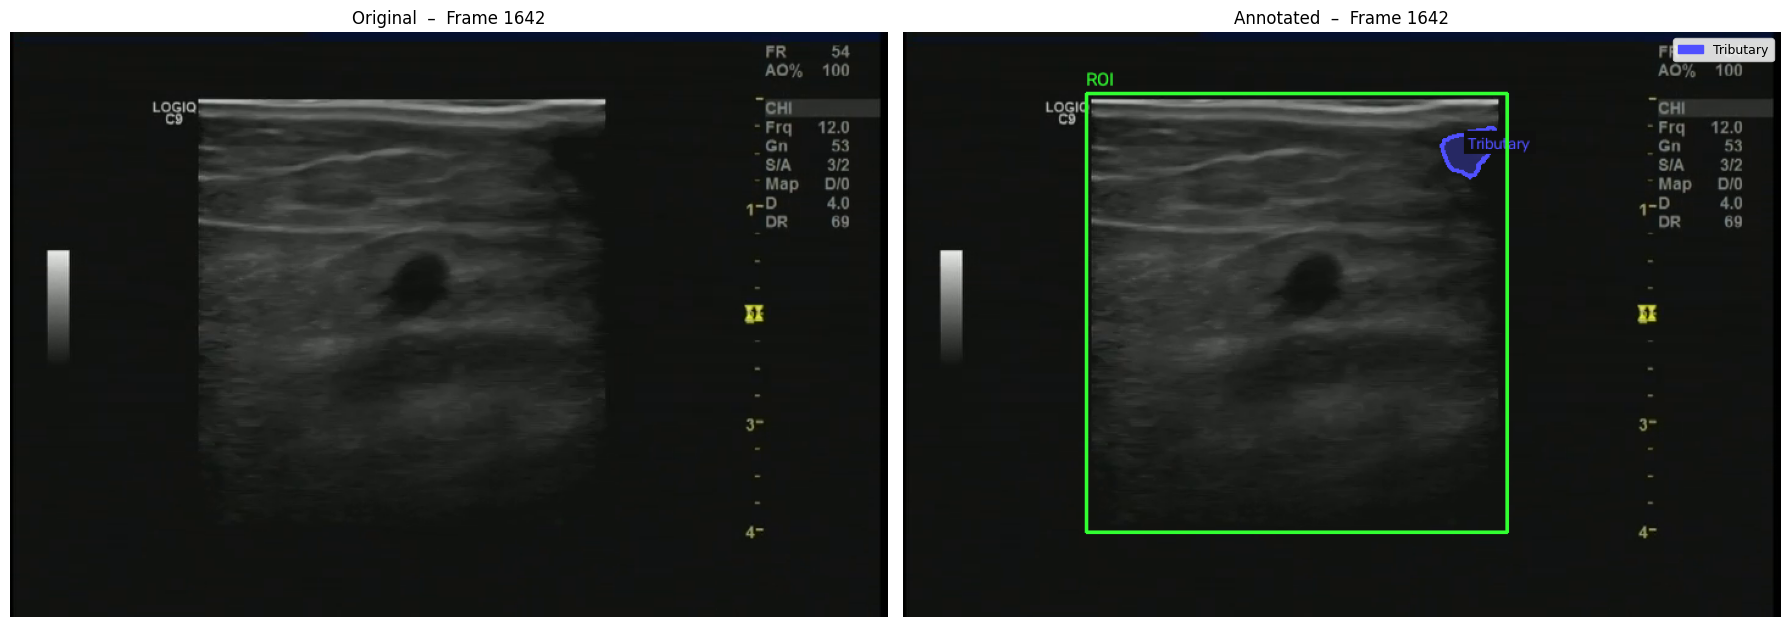

Classes in frame 1642:  ['Tributary']


In [6]:
# ── Cell 4: Static Preview – first annotated frame ────────────────────────────
# Quick sanity check before launching the interactive viewer

preview_idx = FRAME_INDICES[0]
frame = read_frame(preview_idx)
annotated, legend = overlay_masks_on_frame(
    frame, frame_masks[preview_idx], alpha=0.35, show_roi=True, crop_to_roi=False
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Original  –  Frame {preview_idx}", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Annotated  –  Frame {preview_idx}", fontsize=12)
axes[1].axis("off")

if legend:
    patches = [
        mpatches.Patch(color=[v / 255 for v in rgb], label=name)
        for name, rgb in legend
    ]
    axes[1].legend(handles=patches, loc="upper right",
                   fontsize=9, framealpha=0.85, fancybox=True)

plt.tight_layout()
plt.show()
print(f"Classes in frame {preview_idx}: ",
      [CLASS_NAMES[c] for c in sorted(frame_masks[preview_idx])
       if frame_masks[preview_idx][c].any()])

In [7]:
# ── Cell 5: Interactive Frame Viewer ──────────────────────────────────────────
# Slider to navigate frames; buttons to jump between annotated frames.
# Toggle ROI box / crop to ROI; adjust mask opacity.

fig_out = widgets.Output()

# ── Widgets ──
frame_slider = widgets.IntSlider(
    value=FRAME_INDICES[0],
    min=0, max=TOTAL_FRAMES - 1, step=1,
    description="Frame:",
    continuous_update=False,
    layout=widgets.Layout(width="680px"),
    style={"description_width": "60px"},
)

alpha_slider = widgets.FloatSlider(
    value=0.35, min=0.0, max=1.0, step=0.05,
    description="Opacity:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
    style={"description_width": "65px"},
)

show_roi_btn  = widgets.ToggleButton(
    value=True,  description="Show ROI",     button_style="success",
    layout=widgets.Layout(width="110px"))
crop_roi_btn  = widgets.ToggleButton(
    value=False, description="Crop to ROI",  button_style="",
    layout=widgets.Layout(width="110px"))

prev_btn = widgets.Button(
    description="◀ Prev mask", button_style="info",
    layout=widgets.Layout(width="120px"))
next_btn = widgets.Button(
    description="Next mask ▶", button_style="info",
    layout=widgets.Layout(width="120px"))
frame_info = widgets.Label(value="")


# ── Render function ──
def render(frame_idx, alpha, show_roi, crop_roi):
    frame = read_frame(frame_idx)
    if frame is None:
        with fig_out:
            clear_output(wait=True)
            print(f"Could not read frame {frame_idx}")
        return

    masks_dict = frame_masks.get(int(frame_idx), {})
    annotated, legend = overlay_masks_on_frame(
        frame, masks_dict,
        alpha=alpha, show_roi=show_roi, crop_to_roi=crop_roi,
    )
    img_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    active_names = [
        CLASS_NAMES[c] for c in sorted(masks_dict)
        if c < len(CLASS_NAMES) and masks_dict[c].any()
    ]

    with fig_out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.imshow(img_rgb)
        title_suffix = ("  |  " + ", ".join(active_names)) if active_names else "  |  no masks"
        ax.set_title(f"Frame {frame_idx} / {TOTAL_FRAMES - 1}{title_suffix}", fontsize=11)
        ax.axis("off")

        if legend:
            patches = [
                mpatches.Patch(color=[v / 255 for v in rgb], label=name)
                for name, rgb in legend
            ]
            ax.legend(handles=patches, loc="upper right",
                      fontsize=9, framealpha=0.85, fancybox=True)

        plt.tight_layout()
        plt.show()

    frame_info.value = (
        f"Frame {frame_idx}  |  annotated: {bool(active_names)}  |  "
        f"total annotated frames: {len(FRAME_INDICES)}"
    )


# ── Button callbacks ──
def on_prev(_):
    prev = [f for f in FRAME_INDICES if f < frame_slider.value]
    if prev:
        frame_slider.value = prev[-1]

def on_next(_):
    nxt = [f for f in FRAME_INDICES if f > frame_slider.value]
    if nxt:
        frame_slider.value = nxt[0]

prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

def on_change(_):
    render(frame_slider.value, alpha_slider.value,
           show_roi_btn.value, crop_roi_btn.value)

for w in (frame_slider, alpha_slider, show_roi_btn, crop_roi_btn):
    w.observe(on_change, names="value")

# ── Layout & display ──
row1 = widgets.HBox([prev_btn, frame_slider, next_btn])
row2 = widgets.HBox([alpha_slider, show_roi_btn, crop_roi_btn, frame_info])
display(row1, row2, fig_out)
render(frame_slider.value, alpha_slider.value,
       show_roi_btn.value, crop_roi_btn.value)

Output()

Class [4] "CFV"  →  1876 annotated frames


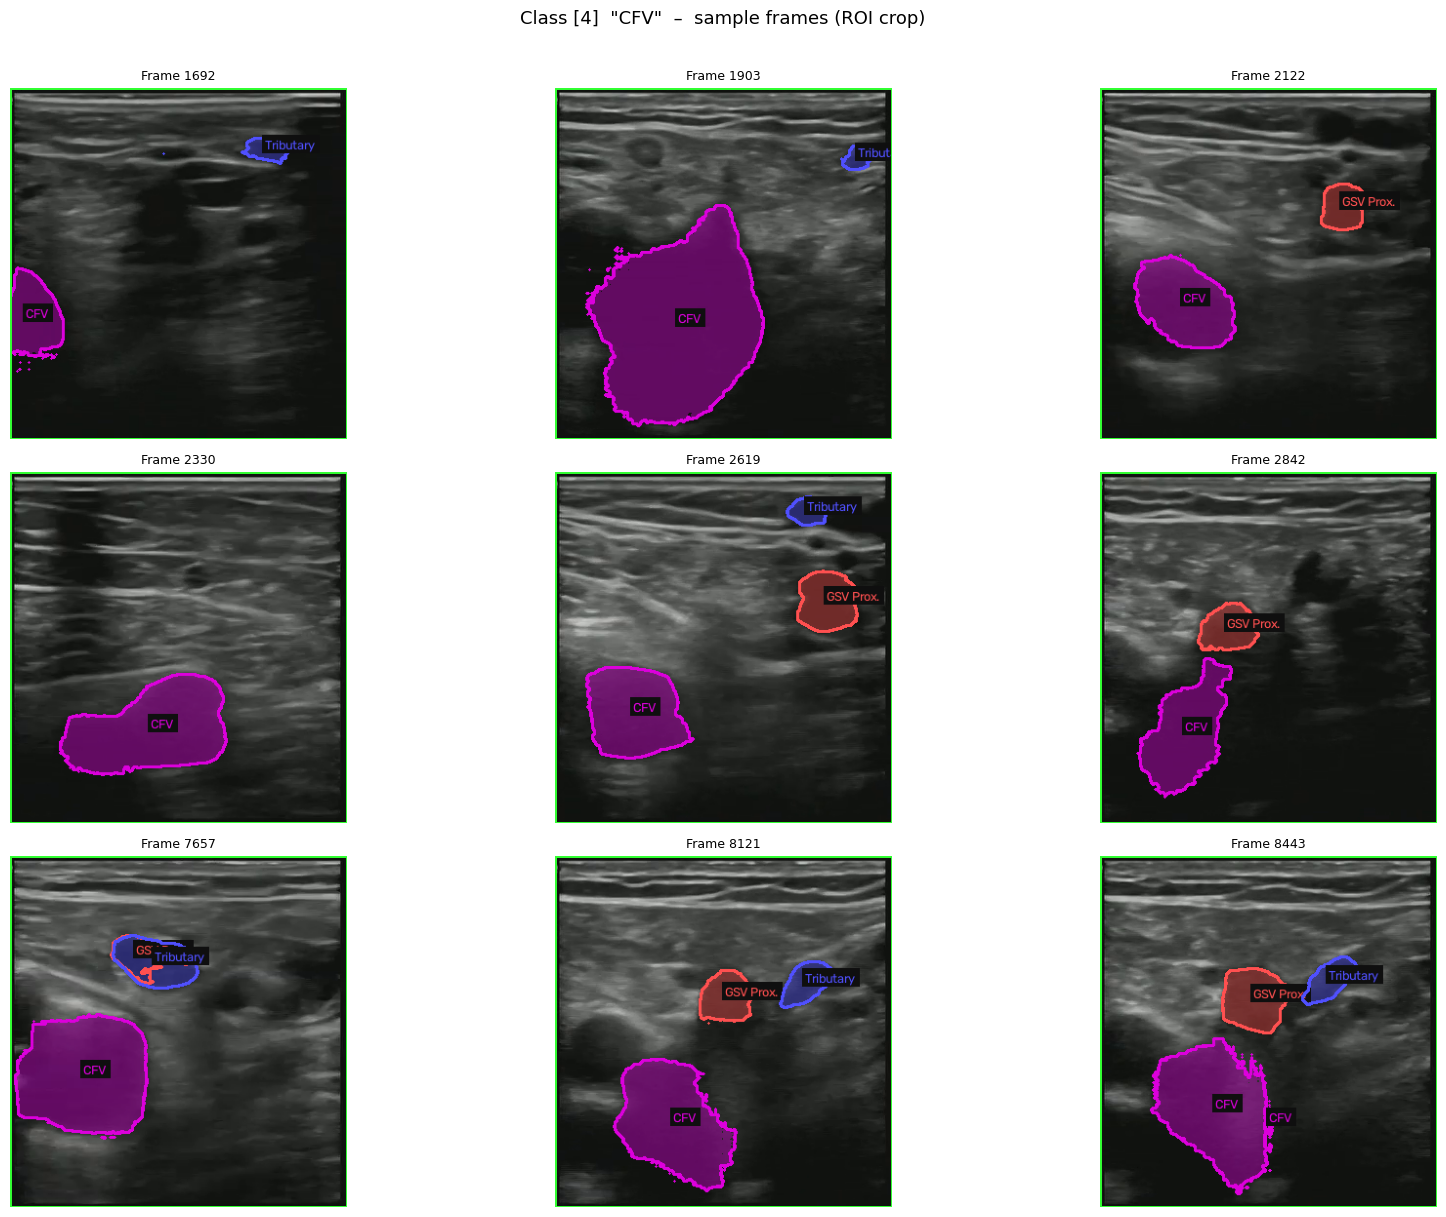

In [8]:
# ── Cell 6: Class-Filtered Gallery ────────────────────────────────────────────
# Show a grid of N sample frames for a chosen class.

TARGET_CLASS_ID = 4          # ← change to whichever class you want to inspect
N_SAMPLES       = 9          # number of frames to show in the grid
GRID_COLS       = 3

target_frames = [
    fi for fi in FRAME_INDICES
    if TARGET_CLASS_ID in frame_masks[fi]
    and frame_masks[fi][TARGET_CLASS_ID].any()
]

class_label = (
    CLASS_NAMES[TARGET_CLASS_ID]
    if TARGET_CLASS_ID < len(CLASS_NAMES)
    else str(TARGET_CLASS_ID)
)
print(f'Class [{TARGET_CLASS_ID}] "{class_label}"  →  {len(target_frames)} annotated frames')

if not target_frames:
    print("No frames found for this class.")
else:
    # Evenly-spaced sample
    step    = max(1, len(target_frames) // N_SAMPLES)
    samples = target_frames[::step][:N_SAMPLES]
    n_rows  = (len(samples) + GRID_COLS - 1) // GRID_COLS

    fig, axes = plt.subplots(n_rows, GRID_COLS,
                              figsize=(GRID_COLS * 6, n_rows * 4))
    axes = np.array(axes).reshape(-1)

    for i, fi in enumerate(samples):
        frame = read_frame(fi)
        if frame is None:
            axes[i].axis("off")
            continue
        ann, _ = overlay_masks_on_frame(
            frame, frame_masks[fi], alpha=0.4, show_roi=True, crop_to_roi=True
        )
        axes[i].imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {fi}", fontsize=9)
        axes[i].axis("off")

    for j in range(len(samples), len(axes)):
        axes[j].axis("off")

    fig.suptitle(f'Class [{TARGET_CLASS_ID}]  "{class_label}"  –  sample frames (ROI crop)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

In [9]:
# ── Cell 7: Export Annotated Video Clip ───────────────────────────────────────
# Writes an MP4 with all overlaid masks for a chosen frame range.
# FRAME_INDICES now only contains frames with actual non-zero annotations,
# so EXPORT_START/END are guaranteed to include visible masks.
#
# To export a custom range, change EXPORT_START and EXPORT_END manually.

EXPORT_START = FRAME_INDICES[0]       # first frame with actual annotations
EXPORT_END   = FRAME_INDICES[-1]      # last  frame with actual annotations
EXPORT_ALPHA = 0.35
EXPORT_PATH  = str(case_dir / f"{CASE_FOLDER}_annotated.mp4")

print(f"Exporting frames {EXPORT_START} – {EXPORT_END}  ({EXPORT_END - EXPORT_START + 1} frames)")
print(f"Output: {EXPORT_PATH}")

cap    = cv2.VideoCapture(str(video_file))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(EXPORT_PATH, fourcc, VIDEO_FPS, (VID_W, VID_H))

cap.set(cv2.CAP_PROP_POS_FRAMES, EXPORT_START)
n_written   = 0
n_annotated = 0
total       = EXPORT_END - EXPORT_START + 1

for fi in range(EXPORT_START, EXPORT_END + 1):
    ret, frame = cap.read()
    if not ret:
        break
    masks_dict = frame_masks.get(fi, {})
    annotated, legend = overlay_masks_on_frame(
        frame, masks_dict, alpha=EXPORT_ALPHA, show_roi=True, crop_to_roi=False
    )
    writer.write(annotated)
    n_written += 1
    if legend:
        n_annotated += 1
    if n_written % 500 == 0:
        print(f"  {n_written}/{total} frames written …")

cap.release()
writer.release()
print(f"\nDone!  {n_written} frames written  ({n_annotated} with visible masks)  →  {EXPORT_PATH}")

Exporting frames 1642 – 55278  (53637 frames)
Output: c:\Users\Krish\Downloads\videos\202401291055_22\202401291055_22_annotated.mp4
  500/53637 frames written …
  1000/53637 frames written …
  1500/53637 frames written …
  2000/53637 frames written …
  2500/53637 frames written …
  3000/53637 frames written …
  3500/53637 frames written …
  4000/53637 frames written …
  4500/53637 frames written …
  5000/53637 frames written …
  5500/53637 frames written …
  6000/53637 frames written …
  6500/53637 frames written …
  7000/53637 frames written …
  7500/53637 frames written …
  8000/53637 frames written …
  8500/53637 frames written …
  9000/53637 frames written …
  9500/53637 frames written …
  10000/53637 frames written …
  10500/53637 frames written …
  11000/53637 frames written …
  11500/53637 frames written …
  12000/53637 frames written …
  12500/53637 frames written …
  13000/53637 frames written …
  13500/53637 frames written …
  14000/53637 frames written …
  14500/53637 frames

In [ ]:
# ── Cell 8: Export All Three Cases to annotated_output/ ──────────────────────
import re, json, numpy as np, cv2
from pathlib import Path

OUTPUT_DIR = Path(BASE_DIR) / "annotated_output"
OUTPUT_DIR.mkdir(exist_ok=True)

def load_masks(masks_dir):
    """
    Handles two NPZ formats:
      Format A  chunk_*.npz          → value is a dict {cls_id: mask}  (case 1)
      Format B  obj_N_chunk_*.npz    → value is the mask directly;
                                        cls_id comes from the filename  (cases 2 & 3)
    Returns {frame_idx (int): {cls_id (int): uint8 mask (H×W)}}
    """
    result = {}
    for npz_path in sorted(Path(masks_dir).glob("*.npz")):
        m = re.match(r"obj_(\d+)_", npz_path.name)
        data = np.load(npz_path, allow_pickle=True)
        if m:
            cls_id = int(m.group(1))
            for key in data.keys():
                fi = int(key)
                if fi not in result:
                    result[fi] = {}
                result[fi][cls_id] = data[key]
        else:
            for key in data.keys():
                result[int(key)] = data[key].item()
    return result


cases = [d for d in sorted(Path(BASE_DIR).iterdir())
         if d.is_dir() and d.name != "annotated_output"]

for case_dir in cases:
    video_file = case_dir / (case_dir.name + ".mp4")
    masks_dir  = case_dir / "masks"
    roi_file   = case_dir / "roi.json"

    if not video_file.exists() or not masks_dir.exists():
        print(f"[SKIP] {case_dir.name}")
        continue

    print(f"\n{'='*60}\nProcessing: {case_dir.name}")

    with open(roi_file) as f:
        cx1, cy1, cx2, cy2 = json.load(f)["crop_region"]

    cap   = cv2.VideoCapture(str(video_file))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    vw    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vh    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f"  {total} frames @ {fps:.2f} fps  |  {vw}x{vh}")

    masks = load_masks(masks_dir)
    print(f"  Loaded masks for {len(masks)} frames")

    out_path = OUTPUT_DIR / (case_dir.name + "_annotated.mp4")
    cap    = cv2.VideoCapture(str(video_file))
    writer = cv2.VideoWriter(str(out_path),
                             cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (vw, vh))

    for fi in range(total):
        ret, frame = cap.read()
        if not ret:
            break

        masks_dict = masks.get(fi, {})
        result     = frame.copy()
        color_fill = np.zeros_like(frame)
        deferred   = []

        for cls_id in sorted(masks_dict):
            if cls_id >= len(CLASS_NAMES):
                continue
            mask = masks_dict[cls_id]
            if not mask.any():
                continue
            r, g, b = CLASS_COLORS_RGB[cls_id % len(CLASS_COLORS_RGB)]
            bgr = (int(b), int(g), int(r))
            color_fill[mask.astype(bool)] = bgr
            contours, _ = cv2.findContours(
                mask.astype(np.uint8) * 255,
                cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            deferred.append((contours, bgr, cls_id))

        filled = color_fill.any(axis=2)
        if filled.any():
            blended = cv2.addWeighted(color_fill, 0.35, result, 0.65, 0)
            result[filled] = blended[filled]

        font = cv2.FONT_HERSHEY_SIMPLEX
        for contours, bgr, cls_id in deferred:
            cv2.drawContours(result, contours, -1, bgr, 2)
            label = CLASS_NAMES[cls_id]
            (tw, th), _ = cv2.getTextSize(label, font, 0.45, 1)
            for cnt in contours:
                if cv2.contourArea(cnt) < 50:
                    continue
                M = cv2.moments(cnt)
                if M["m00"] == 0:
                    continue
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                tx = max(3, min(cx, vw - tw - 6))
                ty = max(th + 6, min(cy, vh - 3))
                cv2.rectangle(result, (tx-3, ty-th-3), (tx+tw+3, ty+3), (15,15,15), -1)
                cv2.putText(result, label, (tx, ty), font, 0.45, bgr, 1, cv2.LINE_AA)

        cv2.rectangle(result, (cx1, cy1), (cx2, cy2), (50, 255, 50), 2)
        writer.write(result)

        if fi % 2000 == 0:
            print(f"  {fi}/{total} frames …")

    cap.release()
    writer.release()
    print(f"  Saved → {out_path}")

print(f"\nAll done! → {OUTPUT_DIR}")

In [10]:
# ── Cell 7: Export Annotated Video Clip ───────────────────────────────────────
# Writes an MP4 with all overlaid masks for a chosen frame range.
# FRAME_INDICES now only contains frames with actual non-zero annotations,
# so EXPORT_START/END are guaranteed to include visible masks.
#
# To export a custom range, change EXPORT_START and EXPORT_END manually.
CASE_FOLDER = "202401291507_47"

EXPORT_START = FRAME_INDICES[0]       # first frame with actual annotations
EXPORT_END   = FRAME_INDICES[-1]      # last  frame with actual annotations
EXPORT_ALPHA = 0.35
EXPORT_PATH  = str(case_dir / f"{CASE_FOLDER}_annotated.mp4")

print(f"Exporting frames {EXPORT_START} – {EXPORT_END}  ({EXPORT_END - EXPORT_START + 1} frames)")
print(f"Output: {EXPORT_PATH}")

cap    = cv2.VideoCapture(str(video_file))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(EXPORT_PATH, fourcc, VIDEO_FPS, (VID_W, VID_H))

cap.set(cv2.CAP_PROP_POS_FRAMES, EXPORT_START)
n_written   = 0
n_annotated = 0
total       = EXPORT_END - EXPORT_START + 1

for fi in range(EXPORT_START, EXPORT_END + 1):
    ret, frame = cap.read()
    if not ret:
        break
    masks_dict = frame_masks.get(fi, {})
    annotated, legend = overlay_masks_on_frame(
        frame, masks_dict, alpha=EXPORT_ALPHA, show_roi=True, crop_to_roi=False
    )
    writer.write(annotated)
    n_written += 1
    if legend:
        n_annotated += 1
    if n_written % 500 == 0:
        print(f"  {n_written}/{total} frames written …")

cap.release()
writer.release()
print(f"\nDone!  {n_written} frames written  ({n_annotated} with visible masks)  →  {EXPORT_PATH}")

Exporting frames 1642 – 55278  (53637 frames)
Output: c:\Users\Krish\Downloads\videos\202401291055_22\202401291507_47_annotated.mp4
  500/53637 frames written …
  1000/53637 frames written …
  1500/53637 frames written …
  2000/53637 frames written …
  2500/53637 frames written …
  3000/53637 frames written …
  3500/53637 frames written …
  4000/53637 frames written …
  4500/53637 frames written …
  5000/53637 frames written …
  5500/53637 frames written …
  6000/53637 frames written …
  6500/53637 frames written …
  7000/53637 frames written …
  7500/53637 frames written …
  8000/53637 frames written …
  8500/53637 frames written …
  9000/53637 frames written …
  9500/53637 frames written …
  10000/53637 frames written …
  10500/53637 frames written …
  11000/53637 frames written …
  11500/53637 frames written …
  12000/53637 frames written …
  12500/53637 frames written …
  13000/53637 frames written …
  13500/53637 frames written …
  14000/53637 frames written …
  14500/53637 frames

Writing a script to get annotated videos of all three videos and put them in a folder

In [3]:
# ── Cell 8: Export All Three Cases to annotated_output/ ──────────────────────
from pathlib import Path
import json, numpy as np, cv2

OUTPUT_DIR = Path(BASE_DIR) / "annotated_output"
OUTPUT_DIR.mkdir(exist_ok=True)

cases = [d for d in sorted(Path(BASE_DIR).iterdir())
         if d.is_dir() and d.name != "annotated_output"]

for case_dir in cases:
    video_file = case_dir / f"{case_dir.name}.mp4"
    masks_dir  = case_dir / "masks"
    roi_file   = case_dir / "roi.json"

    if not video_file.exists() or not masks_dir.exists():
        print(f"[SKIP] {case_dir.name} – missing video or masks")
        continue

    print(f"\n{'='*60}")
    print(f"Processing: {case_dir.name}")

    # ROI
    with open(roi_file) as f:
        cx1, cy1, cx2, cy2 = json.load(f)["crop_region"]

    # Video info
    cap = cv2.VideoCapture(str(video_file))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    vw    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vh    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f"  {total} frames @ {fps:.2f} fps  |  {vw}x{vh}")

    # Load masks
    masks = {}
    for npz_path in sorted(masks_dir.glob("chunk_*.npz")):
        data = np.load(npz_path, allow_pickle=True)
        for key in data.keys():
            masks[int(key)] = data[key].item()
    print(f"  Loaded masks for {len(masks)} frames")

    # Export
    out_path = OUTPUT_DIR / f"{case_dir.name}_annotated.mp4"
    cap    = cv2.VideoCapture(str(video_file))
    writer = cv2.VideoWriter(str(out_path),
                             cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (vw, vh))

    for fi in range(total):
        ret, frame = cap.read()
        if not ret:
            break

        masks_dict = masks.get(fi, {})

        result     = frame.copy()
        color_fill = np.zeros_like(frame)
        deferred   = []

        for cls_id in sorted(masks_dict):
            if cls_id >= len(CLASS_NAMES):
                continue
            mask = masks_dict[cls_id]
            if not mask.any():
                continue
            r, g, b = CLASS_COLORS_RGB[cls_id % len(CLASS_COLORS_RGB)]
            bgr = (int(b), int(g), int(r))
            color_fill[mask.astype(bool)] = bgr
            contours, _ = cv2.findContours(
                mask.astype(np.uint8) * 255,
                cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            deferred.append((contours, bgr, cls_id))

        filled = color_fill.any(axis=2)
        if filled.any():
            blended = cv2.addWeighted(color_fill, 0.35, result, 0.65, 0)
            result[filled] = blended[filled]

        font = cv2.FONT_HERSHEY_SIMPLEX
        for contours, bgr, cls_id in deferred:
            cv2.drawContours(result, contours, -1, bgr, 2)
            label = CLASS_NAMES[cls_id]
            (tw, th), _ = cv2.getTextSize(label, font, 0.45, 1)
            for cnt in contours:
                if cv2.contourArea(cnt) < 50:
                    continue
                M = cv2.moments(cnt)
                if M["m00"] == 0:
                    continue
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                tx = max(3, min(cx, vw - tw - 6))
                ty = max(th + 6, min(cy, vh - 3))
                cv2.rectangle(result, (tx-3, ty-th-3), (tx+tw+3, ty+3), (15,15,15), -1)
                cv2.putText(result, label, (tx, ty), font, 0.45, bgr, 1, cv2.LINE_AA)

        cv2.rectangle(result, (cx1, cy1), (cx2, cy2), (50, 255, 50), 2)

        writer.write(result)

        if fi % 2000 == 0:
            print(f"  {fi}/{total} frames …")

    cap.release()
    writer.release()
    print(f"  Saved → {out_path}")

print(f"\nAll done! Output folder: {OUTPUT_DIR}")


Processing: 202401291055_22
  55589 frames @ 59.94 fps  |  720x480
  Loaded masks for 43404 frames
  0/55589 frames …
  2000/55589 frames …
  4000/55589 frames …
  6000/55589 frames …
  8000/55589 frames …
  10000/55589 frames …
  12000/55589 frames …
  14000/55589 frames …
  16000/55589 frames …
  18000/55589 frames …
  20000/55589 frames …
  22000/55589 frames …
  24000/55589 frames …
  26000/55589 frames …
  28000/55589 frames …
  30000/55589 frames …
  32000/55589 frames …
  34000/55589 frames …
  36000/55589 frames …
  38000/55589 frames …
  40000/55589 frames …
  42000/55589 frames …
  44000/55589 frames …
  46000/55589 frames …
  48000/55589 frames …
  50000/55589 frames …
  52000/55589 frames …
  54000/55589 frames …
  Saved → c:\Users\Krish\Downloads\videos\annotated_output\202401291055_22_annotated.mp4

Processing: 202401291507_47
  59646 frames @ 59.94 fps  |  720x480
  Loaded masks for 0 frames
  0/59646 frames …
  2000/59646 frames …
  4000/59646 frames …
  6000/59646 fra

In [2]:
# ── Cell 8: Export All Three Cases to annotated_output/ ──────────────────────
from pathlib import Path
import json, numpy as np, cv2

OUTPUT_DIR = Path(BASE_DIR) / "annotated_output"
OUTPUT_DIR.mkdir(exist_ok=True)

cases = [d for d in sorted(Path(BASE_DIR).iterdir())
         if d.is_dir() and d.name != "annotated_output"]

for case_dir in cases:
    video_file = case_dir / f"{case_dir.name}.mp4"
    masks_dir  = case_dir / "masks"
    roi_file   = case_dir / "roi.json"

    if not video_file.exists() or not masks_dir.exists():
        print(f"[SKIP] {case_dir.name} – missing video or masks")
        continue

    print(f"\n{'='*60}")
    print(f"Processing: {case_dir.name}")

    # ROI
    with open(roi_file) as f:
        cx1, cy1, cx2, cy2 = json.load(f)["crop_region"]

    # Video info
    cap = cv2.VideoCapture(str(video_file))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    vw    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vh    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f"  {total} frames @ {fps:.2f} fps  |  {vw}x{vh}")

    # Load masks
    masks = {}
    for npz_path in sorted(masks_dir.glob("chunk_*.npz")):
        data = np.load(npz_path, allow_pickle=True)
        for key in data.keys():
            masks[int(key)] = data[key].item()
    print(f"  Loaded masks for {len(masks)} frames")

    # Export
    out_path = OUTPUT_DIR / f"{case_dir.name}_annotated.mp4"
    cap    = cv2.VideoCapture(str(video_file))
    writer = cv2.VideoWriter(str(out_path),
                             cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (vw, vh))

    for fi in range(total):
        ret, frame = cap.read()
        if not ret:
            break

        masks_dict = masks.get(fi, {})

        result     = frame.copy()
        color_fill = np.zeros_like(frame)
        deferred   = []

        for cls_id in sorted(masks_dict):
            if cls_id >= len(CLASS_NAMES):
                continue
            mask = masks_dict[cls_id]
            if not mask.any():
                continue
            r, g, b = CLASS_COLORS_RGB[cls_id % len(CLASS_COLORS_RGB)]
            bgr = (int(b), int(g), int(r))
            color_fill[mask.astype(bool)] = bgr
            contours, _ = cv2.findContours(
                mask.astype(np.uint8) * 255,
                cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            deferred.append((contours, bgr, cls_id))

        filled = color_fill.any(axis=2)
        if filled.any():
            blended = cv2.addWeighted(color_fill, 0.35, result, 0.65, 0)
            result[filled] = blended[filled]

        font = cv2.FONT_HERSHEY_SIMPLEX
        for contours, bgr, cls_id in deferred:
            cv2.drawContours(result, contours, -1, bgr, 2)
            label = CLASS_NAMES[cls_id]
            (tw, th), _ = cv2.getTextSize(label, font, 0.45, 1)
            for cnt in contours:
                if cv2.contourArea(cnt) < 50:
                    continue
                M = cv2.moments(cnt)
                if M["m00"] == 0:
                    continue
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                tx = max(3, min(cx, vw - tw - 6))
                ty = max(th + 6, min(cy, vh - 3))
                cv2.rectangle(result, (tx-3, ty-th-3), (tx+tw+3, ty+3), (15,15,15), -1)
                cv2.putText(result, label, (tx, ty), font, 0.45, bgr, 1, cv2.LINE_AA)

        cv2.rectangle(result, (cx1, cy1), (cx2, cy2), (50, 255, 50), 2)

        writer.write(result)

        if fi % 2000 == 0:
            print(f"  {fi}/{total} frames …")

    cap.release()
    writer.release()
    print(f"  Saved → {out_path}")

print(f"\nAll done! Output folder: {OUTPUT_DIR}")


Processing: 202401291055_22
  55589 frames @ 59.94 fps  |  720x480
  Loaded masks for 43404 frames
  0/55589 frames …
  2000/55589 frames …
  4000/55589 frames …
  6000/55589 frames …
  8000/55589 frames …
  10000/55589 frames …
  12000/55589 frames …
  14000/55589 frames …
  16000/55589 frames …
  18000/55589 frames …
  20000/55589 frames …
  22000/55589 frames …
  24000/55589 frames …
  26000/55589 frames …
  28000/55589 frames …
  30000/55589 frames …
  32000/55589 frames …
  34000/55589 frames …
  36000/55589 frames …
  38000/55589 frames …
  40000/55589 frames …
  42000/55589 frames …
  44000/55589 frames …
  46000/55589 frames …
  48000/55589 frames …
  50000/55589 frames …
  52000/55589 frames …
  54000/55589 frames …
  Saved → c:\Users\Krish\Downloads\videos\annotated_output\202401291055_22_annotated.mp4

Processing: 202401291507_47
  59646 frames @ 59.94 fps  |  720x480
  Loaded masks for 0 frames
  0/59646 frames …
  2000/59646 frames …
  4000/59646 frames …
  6000/59646 fra